# Physical gate optimization

This notebook constructs reproducible `GateSpec`s for two 10 ns Gaussian
X gates and a tunable iSWAP. Frequencies and Hamiltonian coefficients are in
GHz, times are in ns, and `QuantumDevices` therefore propagates with `2πH`.
The values are representative rather than calibrated to a specific chip.

In [1]:
using Pkg
project_root =
    isfile(joinpath(pwd(), "Project.toml")) ? pwd() : abspath(joinpath(pwd(), ".."))
if Base.active_project() != joinpath(project_root, "Project.toml") &&
   Base.find_package("QuantumDevices") === nothing
    Pkg.activate(project_root)
end

using CairoMakie
using LinearAlgebra
using Markdown
import QuantumDevices as QD
import QuantumToolbox as QT

CairoMakie.activate!(type = "png")

## Independent propagation helpers

Optimizer metrics are checked below by propagating each complete gate
Hamiltonian again with QuantumToolbox.

In [2]:
function labeled_basis(built, labels)
    hcat([vec(ComplexF64.(Array(built.states[label].data))) for label in labels]...)
end

function independent_metrics(gate, objective)
    built = QD.model(gate.modelspec)
    hamiltonian = QD.numerical(built, gate)
    initial = QT.qeye_like(hamiltonian)
    initial = initial isa QT.QuantumObjectEvolution ? initial(nothing, 0.0) : initial
    propagator = QT.sesolve(
        2π*hamiltonian,
        initial,
        [0.0, gate.duration];
        progress_bar = Val(false),
    ).states[end]
    basis = labeled_basis(built, objective.states)
    logical = adjoint(basis) * Matrix(propagator.data) * basis
    fidelity = abs(tr(adjoint(objective.target) * logical))^2 / size(logical, 1)^2
    survival = real(tr(adjoint(logical) * logical)) / size(logical, 1)
    (; fidelity = Float64(real(fidelity)), leakage = max(0.0, 1.0 - survival))
end

function state_populations(gate, initial_label, labels; samples = 301)
    built = QD.model(gate.modelspec)
    times = collect(range(0.0, gate.duration; length = samples))
    initial = QT.QuantumObject(
        vec(ComplexF64.(Array(built.states[initial_label].data)));
        type = QT.Ket(),
        dims = Tuple(built.spec.dimension),
    )
    solution = QT.sesolve(
        2π * QD.numerical(built, gate),
        initial,
        times;
        progress_bar = Val(false),
    )
    populations = Dict(
        label => begin
            reference = vec(ComplexF64.(Array(built.states[label].data)))
            [abs(dot(reference, vec(Array(state.data))))^2 for state in solution.states]
        end for label in labels
    )
    (; times, populations)
end

state_populations (generic function with 1 method)

## Gaussian X gates

Each effective qubit is modeled in its microwave rotating frame. The physical
carrier frequency is retained in component metadata. The control is the Rabi
frequency Ω(t) in GHz and enters the Hamiltonian as `Ω(t)X/2`.

In [3]:
const X_DURATION = 10.0
const X_SIGMA = 2.0
const X_TARGET = ComplexF64[0 1; 1 0]
const X_STATES = [(0,), (1,)]
const X_OBJECTIVE = QD.UnitaryObjective(X_TARGET; states = X_STATES)

function endpoint_gaussian(t, duration = X_DURATION, sigma = X_SIGMA)
    edge = exp(-0.5 * (duration / (2sigma))^2)
    raw = exp(-0.5 * ((t - duration / 2) / sigma)^2)
    (raw - edge) / (1 - edge)
end

function x_problem(name, carrier_frequency)
    qubit = QD.Component(
        QD.QubitSpec(
            0.0;
            fixed_frequency = true,
            metadata = Dict(:frame_frequency_GHz => carrier_frequency, :time_unit => :ns),
        ),
        :q,
    )
    drive = QD.DeviceParameter(
        :drive;
        domain = QD.realdomain(),
        fixed = false,
        default = 0.0,
        description = "Rotating-frame Rabi frequency in GHz.",
    )
    spec = QD.ModelSpec(
        name,
        [qubit];
        interactions = (QD.param(drive) * QD.op(:q, :x) / 2,),
        parameters = (drive,),
        dressingspec = QD.DressingSpec(minimum_overlap = 0),
    )
    path = QD.ParamPath(:drive)
    gate = QD.GateSpec(
        name,
        spec;
        duration = X_DURATION,
        parameters = (peak_rabi = 0.10, sigma = X_SIGMA),
        controls = Dict(
            path => ((p, time) ->
                p.peak_rabi * endpoint_gaussian(time, p.duration, p.sigma)),
        ),
    )
    (; spec, path, gate, carrier_frequency)
end

xq1 = x_problem(:x_q1, 4.8)
xq2 = x_problem(:x_q2, 5.2)
x_initial = [xq1.gate, xq2.gate]
x_results = [
    QD.optimize(xq1.gate, X_TARGET, :peak_rabi => (0.0, 0.20); iterations = 80),
    QD.optimize(xq2.gate, X_TARGET, :peak_rabi => (0.0, 0.20); iterations = 80),
]

for (fixture, result) in zip((xq1, xq2), x_results)
    @assert result.gate.duration == X_DURATION
    @assert 0.0 <= result.minimizer[:peak_rabi] <= 0.20
    @assert result.gate.controls[fixture.path](0.0) == 0.0
    @assert result.gate.controls[fixture.path](X_DURATION) == 0.0
    verified = independent_metrics(result.gate, X_OBJECTIVE)
    @assert isapprox(verified.fidelity, result.fidelity; atol = 1e-8)
    @assert isapprox(verified.leakage, result.leakage; atol = 1e-8)
end

x_summary = [
    (
        gate = result.gate.name,
        carrier_GHz = fixture.carrier_frequency,
        initial_fidelity = independent_metrics(initial, X_OBJECTIVE).fidelity,
        optimized_peak_MHz = 1000 * result.minimizer[:peak_rabi],
        fidelity = result.fidelity,
        leakage = result.leakage,
    ) for (fixture, initial, result) in zip((xq1, xq2), x_initial, x_results)
]
x_summary

2-element Vector{@NamedTuple{gate::Symbol, carrier_GHz::Float64, initial_fidelity::Float64, optimized_peak_MHz::Float64, fidelity::Float64, leakage::Float64}}:
 (gate = :x_q1, carrier_GHz = 4.8, initial_fidelity = 0.9922250213971873, optimized_peak_MHz = 105.95550537109376, fidelity = 0.9999999963827426, leakage = 3.6172025374980876e-9)
 (gate = :x_q2, carrier_GHz = 5.2, initial_fidelity = 0.9922250213971873, optimized_peak_MHz = 105.95550537109376, fidelity = 0.9999999963827426, leakage = 3.6172025374980876e-9)

The builder-oriented API remains useful when candidate construction is more
general than named gate reconstruction.

In [4]:
low_level_problem = QD.EnvelopeOptimizationProblem(
    values -> QD.with_parameters(xq1.gate; peak_rabi = values.peak_rabi),
    [QD.GateVariable(:peak_rabi; initial = 0.10, lower = 0.0, upper = 0.20)],
    X_OBJECTIVE,
)

QuantumDevices.EnvelopeOptimizationProblem{var"#35#36", QuantumDevices.UnitaryObjective{Matrix{ComplexF64}, Tuple{Tuple{Int64}, Tuple{Int64}}}}(var"#35#36"(), QuantumDevices.GateVariable[QuantumDevices.GateVariable(:peak_rabi, 0.1, 0.0, 0.2)], QuantumDevices.UnitaryObjective{Matrix{ComplexF64}, Tuple{Tuple{Int64}, Tuple{Int64}}}(ComplexF64[0.0 + 0.0im 1.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im], ((0,), (1,)), 1.0), Dict{Symbol, Any}())

The exact-zero Gaussian satisfies the gate endpoint invariant while retaining
a familiar smooth shape.

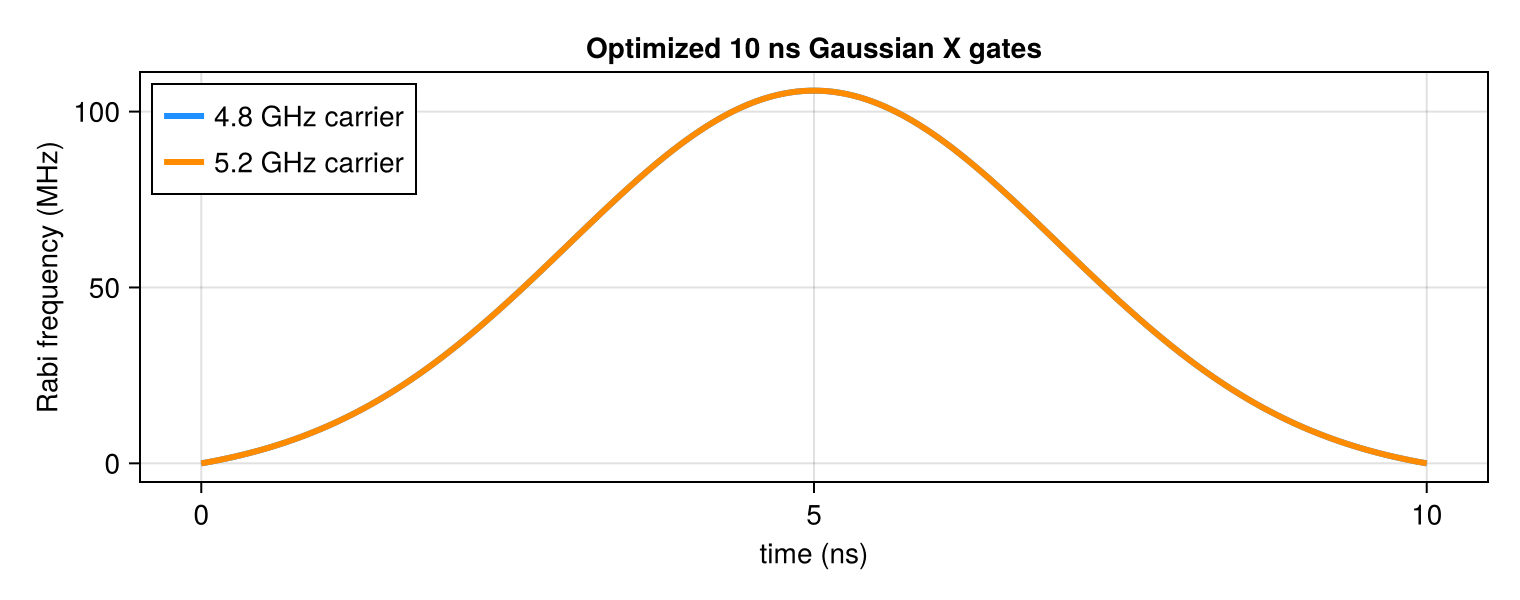

In [5]:
x_times = collect(range(0.0, X_DURATION; length = 301))
x_figure = Figure(size = (760, 300))
x_axis = Axis(
    x_figure[1, 1];
    title = "Optimized 10 ns Gaussian X gates",
    xlabel = "time (ns)",
    ylabel = "Rabi frequency (MHz)",
)
for (fixture, result, color) in zip((xq1, xq2), x_results, (:dodgerblue, :darkorange))
    lines!(
        x_axis,
        x_times,
        1000 .* [result.gate.controls[fixture.path](time) for time in x_times];
        label = "$(fixture.carrier_frequency) GHz carrier",
        linewidth = 3,
        color,
    )
end
axislegend(x_axis; position = :lt)
x_figure

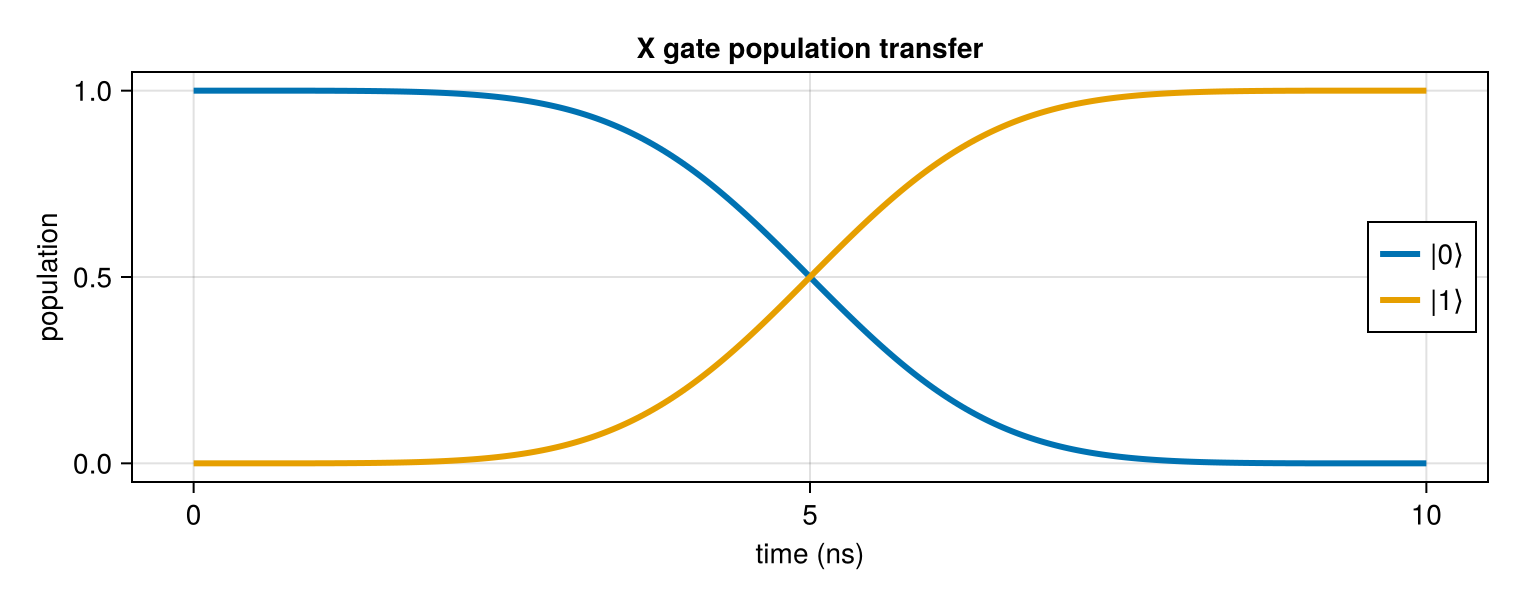

In [6]:
x_population = state_populations(x_results[1].gate, (0,), X_STATES)
x_population_figure = Figure(size = (760, 300))
x_population_axis = Axis(
    x_population_figure[1, 1];
    title = "X gate population transfer",
    xlabel = "time (ns)",
    ylabel = "population",
)
lines!(
    x_population_axis,
    x_population.times,
    x_population.populations[(0,)];
    label = "|0⟩",
    linewidth = 3,
)
lines!(
    x_population_axis,
    x_population.times,
    x_population.populations[(1,)];
    label = "|1⟩",
    linewidth = 3,
)
axislegend(x_population_axis; position = :rc)
x_population_figure

## Tunable iSWAP

A 4.5 GHz common frame offset is removed numerically. The remaining fixed
0.5 GHz term plus idle detunings of ±0.2 GHz represents physical qubit
frequencies of 4.8 and 5.2 GHz. A tunable exchange channel is off at idle and
reaches 12 MHz during the flat top.

In [7]:
const REFERENCE_FREQUENCY = 5.0
const FRAME_OFFSET = 4.5
const IDLE_Q1 = -0.20
const IDLE_Q2 = 0.20
const EXCHANGE = 0.012
const ISWAP_STATES = [(0, 0), (0, 1), (1, 0), (1, 1)]
const ISWAP_TARGET = ComplexF64[
    1 0 0 0
    0 0 im 0
    0 im 0 0
    0 0 0 1
]
const ISWAP_OBJECTIVE = QD.UnitaryObjective(ISWAP_TARGET; states = ISWAP_STATES)

function cos2_flattop(t, duration, ramp_time)
    t <= 0 && return 0.0
    t >= duration && return 0.0
    t < ramp_time && return sinpi(t / (2ramp_time))^2
    t > duration - ramp_time && return sinpi((duration - t) / (2ramp_time))^2
    1.0
end

function iswap_fixture()
    q1 = QD.Component(
        QD.QubitSpec(
            REFERENCE_FREQUENCY - FRAME_OFFSET;
            fixed_frequency = true,
            metadata = Dict(:frame_offset_GHz => FRAME_OFFSET),
        ),
        :q1,
    )
    q2 = QD.Component(
        QD.QubitSpec(
            REFERENCE_FREQUENCY - FRAME_OFFSET;
            fixed_frequency = true,
            metadata = Dict(:frame_offset_GHz => FRAME_OFFSET),
        ),
        :q2,
    )
    q1_shift = QD.DeviceParameter(
        :q1_shift;
        domain = QD.realdomain(),
        fixed = false,
        default = 0.0,
        description = "Qubit 1 detuning shift in GHz.",
    )
    q2_shift = QD.DeviceParameter(
        :q2_shift;
        domain = QD.realdomain(),
        fixed = false,
        default = 0.0,
        description = "Qubit 2 detuning shift in GHz.",
    )
    exchange = QD.DeviceParameter(
        :exchange;
        domain = QD.realdomain(),
        fixed = false,
        default = 0.0,
        description = "Activated exchange rate in GHz.",
    )
    interaction =
        -QD.param(exchange) *
        (QD.op(:q1, :p) * QD.op(:q2, :m) + QD.op(:q1, :m) * QD.op(:q2, :p))
    spec = QD.ModelSpec(
        :iswap_model,
        [q1, q2];
        interactions = (
            (IDLE_Q1 + QD.param(q1_shift)) * QD.op(:q1, :z) / 2,
            (IDLE_Q2 + QD.param(q2_shift)) * QD.op(:q2, :z) / 2,
            interaction,
        ),
        parameters = (q1_shift, q2_shift, exchange),
        dressingspec = QD.DressingSpec(minimum_overlap = 0),
    )
    (;
        spec,
        q1_path = QD.ParamPath(:q1_shift),
        q2_path = QD.ParamPath(:q2_shift),
        exchange_path = QD.ParamPath(:exchange),
    )
end

iswap = iswap_fixture()
iswap_initial_values =
    (duration = 26.0, ramp_time = 4.0, q1_detuning = 0.0, q2_detuning = 0.0)
iswap_gate = QD.GateSpec(
    :iswap,
    iswap.spec;
    duration = iswap_initial_values.duration,
    parameters = (
        ramp_time = iswap_initial_values.ramp_time,
        q1_detuning = iswap_initial_values.q1_detuning,
        q2_detuning = iswap_initial_values.q2_detuning,
    ),
    controls = Dict(
        iswap.q1_path => ((p, time) ->
            (p.q1_detuning - IDLE_Q1) * cos2_flattop(time, p.duration, p.ramp_time)),
        iswap.q2_path => ((p, time) ->
            (p.q2_detuning - IDLE_Q2) * cos2_flattop(time, p.duration, p.ramp_time)),
        iswap.exchange_path => ((p, time) ->
            EXCHANGE * cos2_flattop(time, p.duration, p.ramp_time)),
    ),
)
iswap_initial_gate = iswap_gate
iswap_initial_metrics = independent_metrics(iswap_initial_gate, ISWAP_OBJECTIVE)
iswap_result = QD.optimize(
    iswap_gate,
    ISWAP_TARGET,
    (
        :duration => (24.0, 60.0),
        :ramp_time => (2.0, 8.0),
        :q1_detuning => (-0.05, 0.05),
        :q2_detuning => (-0.05, 0.05),
    );
    states = ISWAP_STATES,
    iterations = 200,
)
iswap_verified = independent_metrics(iswap_result.gate, ISWAP_OBJECTIVE)

@assert 24.0 <= iswap_result.gate.duration <= 60.0
@assert 2.0 <= iswap_result.minimizer[:ramp_time] <= 8.0
@assert -0.05 <= iswap_result.minimizer[:q1_detuning] <= 0.05
@assert -0.05 <= iswap_result.minimizer[:q2_detuning] <= 0.05
@assert iswap_result.fidelity >= iswap_initial_metrics.fidelity
@assert isfinite(iswap_result.fidelity)
@assert isapprox(iswap_verified.fidelity, iswap_result.fidelity; atol = 1e-8)
@assert isapprox(iswap_verified.leakage, iswap_result.leakage; atol = 1e-8)
for path in (iswap.q1_path, iswap.q2_path, iswap.exchange_path)
    @assert iswap_result.gate.controls[path](0.0) == 0.0
    @assert iswap_result.gate.controls[path](iswap_result.gate.duration) == 0.0
end

iswap_summary = (
    initial_fidelity = iswap_initial_metrics.fidelity,
    duration_ns = iswap_result.minimizer[:duration],
    ramp_ns = iswap_result.minimizer[:ramp_time],
    q1_plateau_GHz = REFERENCE_FREQUENCY + iswap_result.minimizer[:q1_detuning],
    q2_plateau_GHz = REFERENCE_FREQUENCY + iswap_result.minimizer[:q2_detuning],
    exchange_MHz = 1000 * EXCHANGE,
    fidelity = clamp(iswap_result.fidelity, 0.0, 1.0),
    leakage = iswap_result.leakage,
)
iswap_summary

(initial_fidelity = 0.9961254634765623, duration_ns = 26.01629170780519, ramp_ns = 4.220857560199573, q1_plateau_GHz = 5.000729995801473, q2_plateau_GHz = 4.9985221049378215, exchange_MHz = 12.0, fidelity = 1.0, leakage = 0.0)

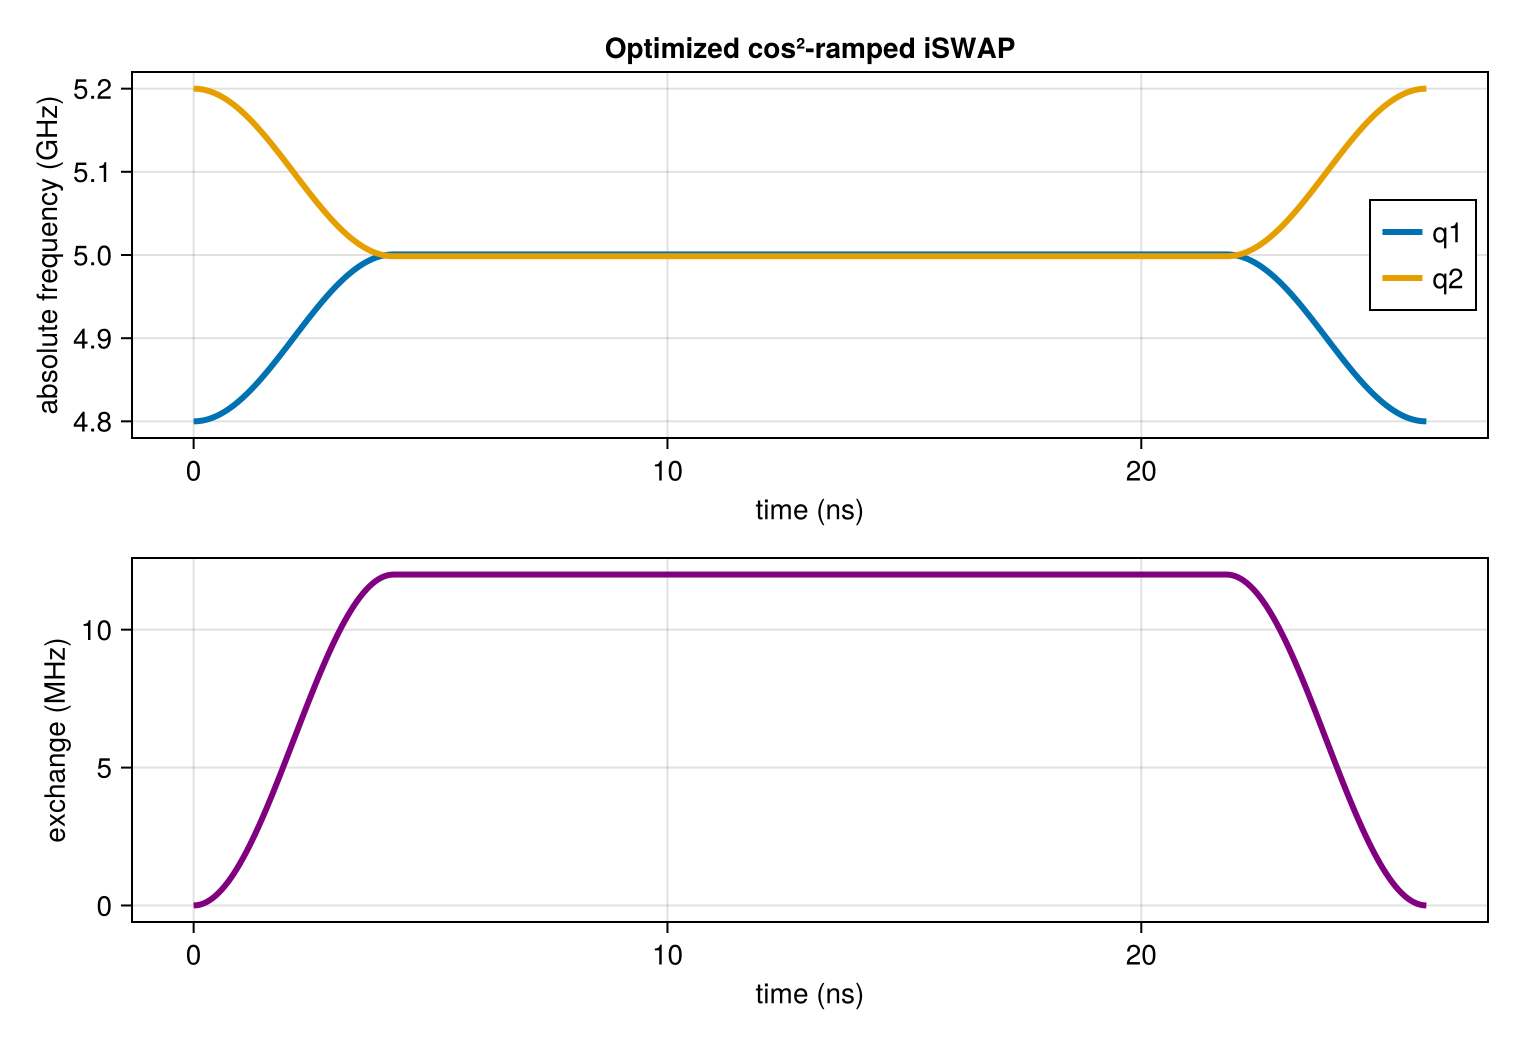

In [8]:
iswap_times = collect(range(0.0, iswap_result.gate.duration; length = 401))
q1_detunings =
    IDLE_Q1 .+ [iswap_result.gate.controls[iswap.q1_path](time) for time in iswap_times]
q2_detunings =
    IDLE_Q2 .+ [iswap_result.gate.controls[iswap.q2_path](time) for time in iswap_times]
exchange_rates =
    1000 .* [iswap_result.gate.controls[iswap.exchange_path](time) for time in iswap_times]

iswap_pulse_figure = Figure(size = (760, 520))
frequency_axis = Axis(
    iswap_pulse_figure[1, 1];
    title = "Optimized cos²-ramped iSWAP",
    xlabel = "time (ns)",
    ylabel = "absolute frequency (GHz)",
)
lines!(
    frequency_axis,
    iswap_times,
    REFERENCE_FREQUENCY .+ q1_detunings;
    label = "q1",
    linewidth = 3,
)
lines!(
    frequency_axis,
    iswap_times,
    REFERENCE_FREQUENCY .+ q2_detunings;
    label = "q2",
    linewidth = 3,
)
axislegend(frequency_axis; position = :rc)
exchange_axis =
    Axis(iswap_pulse_figure[2, 1]; xlabel = "time (ns)", ylabel = "exchange (MHz)")
lines!(exchange_axis, iswap_times, exchange_rates; linewidth = 3, color = :purple)
iswap_pulse_figure

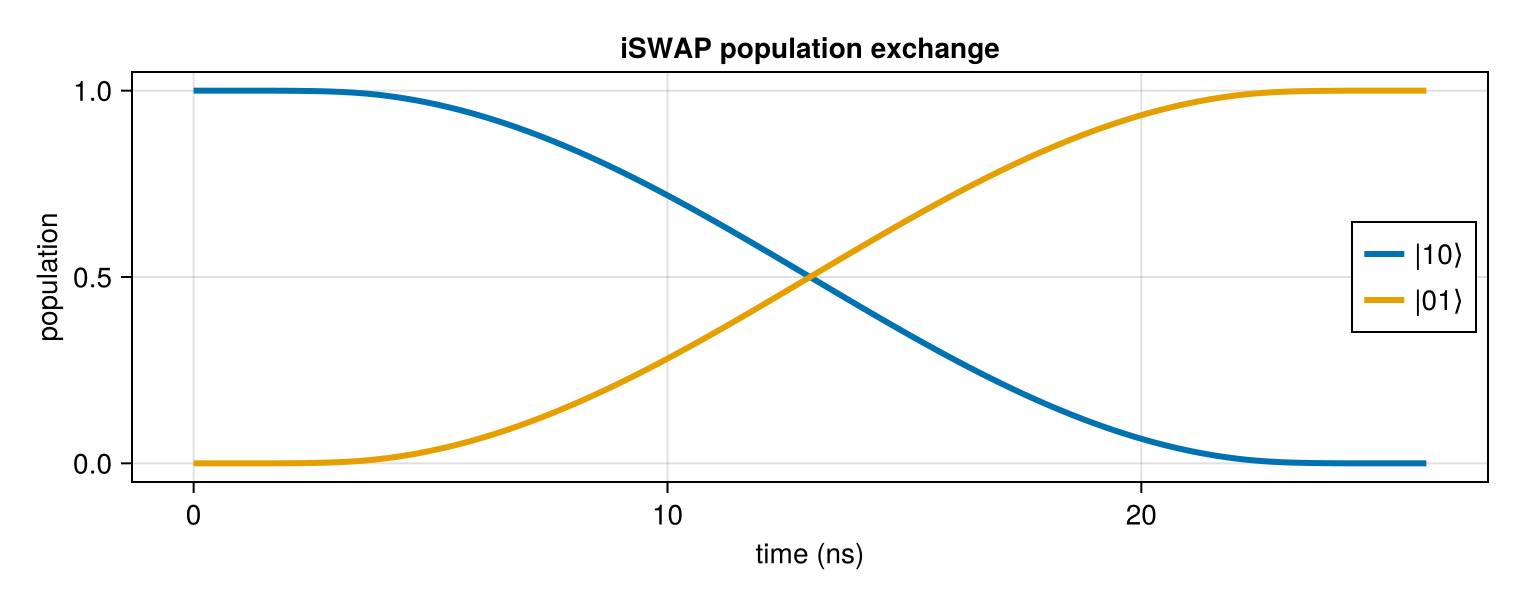

In [9]:
iswap_population = state_populations(iswap_result.gate, (1, 0), [(1, 0), (0, 1)])
iswap_population_figure = Figure(size = (760, 300))
iswap_population_axis = Axis(
    iswap_population_figure[1, 1];
    title = "iSWAP population exchange",
    xlabel = "time (ns)",
    ylabel = "population",
)
lines!(
    iswap_population_axis,
    iswap_population.times,
    iswap_population.populations[(1, 0)];
    label = "|10⟩",
    linewidth = 3,
)
lines!(
    iswap_population_axis,
    iswap_population.times,
    iswap_population.populations[(0, 1)];
    label = "|01⟩",
    linewidth = 3,
)
axislegend(iswap_population_axis; position = :rc)
iswap_population_figure

## Optional Piccolo synthesis

Piccolo remains a weak dependency. If it is unavailable in this Julia
environment, the classical examples above still run. To keep the core project
unchanged, install Piccolo into a separate environment and develop this
checkout into it:

```sh
julia --project=/path/to/piccolo-demo -e \
  'using Pkg; Pkg.develop(path="/path/to/QuantumDevices"); Pkg.add(["Piccolo", "IJulia"])'
```

Then launch this notebook with that environment's IJulia kernel.

In [10]:
piccolo_available = Base.find_package("Piccolo") !== nothing
if piccolo_available
    @eval import Piccolo
    md"Piccolo is available; running three independent synthesis problems."
else
    md"Piccolo is not installed in the active environment, so only this optional section is skipped."
end

Piccolo is not installed in the active environment, so only this optional section is skipped.


In [11]:
piccolo_results = if piccolo_available
    function independent_x_piccolo(fixture)
        knots = 31
        seed_gate = QD.GateSpec(
            Symbol("piccolo_seed_", fixture.spec.name),
            fixture.spec;
            duration = X_DURATION,
            controls = Dict(
                fixture.path => (time -> 0.02 * sinpi(time / X_DURATION)^2),
            ),
        )
        QD.optimize(
            seed_gate,
            X_TARGET,
            fixture.path => (-0.20, 0.20);
            backend = :piccolo,
            states = X_STATES,
            knots,
            template_kwargs = Dict(:Q => 500.0, :R => 1e-3, :ddu_bound => 0.10),
            solve_kwargs = Dict(:max_iter => 60, :verbose => false, :print_level => 0),
        )
    end

    piccolo_x1 = independent_x_piccolo(xq1)
    piccolo_x2 = independent_x_piccolo(xq2)

    swap_knots = 41
    piccolo_iswap_seed = QD.GateSpec(
        :piccolo_iswap_seed,
        iswap.spec;
        duration = iswap_result.gate.duration,
        controls = Dict(
            iswap.q1_path => (time ->
                -IDLE_Q1 * sinpi(time / iswap_result.gate.duration)^2),
            iswap.q2_path => (time ->
                -IDLE_Q2 * sinpi(time / iswap_result.gate.duration)^2),
            iswap.exchange_path => (time ->
                0.5 * EXCHANGE * sinpi(time / iswap_result.gate.duration)^2),
        ),
    )
    piccolo_iswap = QD.optimize(
        piccolo_iswap_seed,
        ISWAP_TARGET,
        (
            iswap.q1_path => (0.0, 0.25),
            iswap.q2_path => (-0.25, 0.0),
            iswap.exchange_path => (-EXCHANGE, EXCHANGE),
        );
        backend = :piccolo,
        states = ISWAP_STATES,
        knots = swap_knots,
        template_kwargs = Dict(:Q => 1000.0, :R => 1e-3, :ddu_bound => 0.10),
        solve_kwargs = Dict(:max_iter => 100, :verbose => false, :print_level => 0),
    )

    for (fixture, result) in zip((xq1, xq2), (piccolo_x1, piccolo_x2))
        local x_verified = independent_metrics(result.gate, X_OBJECTIVE)
        @assert isapprox(x_verified.fidelity, result.fidelity; atol = 1e-8)
        @assert result.gate.controls[fixture.path](0.0) == 0.0
        @assert result.gate.controls[fixture.path](X_DURATION) == 0.0
    end
    iswap_piccolo_verified = independent_metrics(piccolo_iswap.gate, ISWAP_OBJECTIVE)
    @assert isapprox(iswap_piccolo_verified.fidelity, piccolo_iswap.fidelity; atol = 1e-8)
    for path in (iswap.q1_path, iswap.q2_path, iswap.exchange_path)
        @assert piccolo_iswap.gate.controls[path](0.0) == 0.0
        @assert piccolo_iswap.gate.controls[path](piccolo_iswap.gate.duration) == 0.0
    end

    (x1 = piccolo_x1, x2 = piccolo_x2, iswap = piccolo_iswap)
else
    nothing
end

In [12]:
if piccolo_available
    piccolo_summary = [
        (
            gate = result.gate.name,
            duration_ns = result.gate.duration,
            fidelity = result.fidelity,
            leakage = result.leakage,
            backend = result.settings[:backend],
            diagnostic_type = nameof(typeof(result.backend_result)),
        ) for result in (piccolo_results.x1, piccolo_results.x2, piccolo_results.iswap)
    ]
    piccolo_summary
end

In [13]:
if piccolo_available
    comparison_times = collect(range(0.0, X_DURATION; length = 301))
    piccolo_comparison = Figure(size = (760, 300))
    comparison_axis = Axis(
        piccolo_comparison[1, 1];
        title = "Classical Gaussian and independent Piccolo X pulse",
        xlabel = "time (ns)",
        ylabel = "Rabi frequency (MHz)",
    )
    lines!(
        comparison_axis,
        comparison_times,
        1000 .* [x_results[1].gate.controls[xq1.path](time) for time in comparison_times];
        label = "classical Gaussian",
        linewidth = 3,
    )
    stairs!(
        comparison_axis,
        comparison_times,
        1000 .*
        [piccolo_results.x1.gate.controls[xq1.path](time) for time in comparison_times];
        label = "Piccolo",
        linewidth = 2,
    )
    axislegend(comparison_axis; position = :lt)
    piccolo_comparison
end

In [14]:
if piccolo_available
    comparison_times =
        collect(range(0.0, piccolo_results.iswap.gate.duration; length = 401))
    piccolo_iswap_figure = Figure(size = (760, 520))
    detuning_axis = Axis(
        piccolo_iswap_figure[1, 1];
        title = "Independent Piccolo iSWAP controls",
        xlabel = "time (ns)",
        ylabel = "absolute frequency (GHz)",
    )
    lines!(
        detuning_axis,
        comparison_times,
        REFERENCE_FREQUENCY .+ IDLE_Q1 .+ [
            piccolo_results.iswap.gate.controls[iswap.q1_path](time) for
            time in comparison_times
        ];
        label = "q1",
        linewidth = 2,
    )
    lines!(
        detuning_axis,
        comparison_times,
        REFERENCE_FREQUENCY .+ IDLE_Q2 .+ [
            piccolo_results.iswap.gate.controls[iswap.q2_path](time) for
            time in comparison_times
        ];
        label = "q2",
        linewidth = 2,
    )
    axislegend(detuning_axis; position = :rc)
    exchange_axis =
        Axis(piccolo_iswap_figure[2, 1]; xlabel = "time (ns)", ylabel = "exchange (MHz)")
    stairs!(
        exchange_axis,
        comparison_times,
        1000 .* [
            piccolo_results.iswap.gate.controls[iswap.exchange_path](time) for
            time in comparison_times
        ];
        linewidth = 2,
        color = :purple,
    )
    piccolo_iswap_figure
end

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*